# 여성의류 리뷰 데이터 EDA 실습 노트북

이 노트북에서는 여성의류 라벨링 데이터(JSON)를 이용해 다음과 같은 탐색적 데이터 분석(EDA)을 수행합니다.

1. 데이터 기본 구조 및 결측치 확인
2. 리뷰 길이(문자 수, 단어 수) 분포 분석
3. 리뷰 날짜 분포 분석
4. ReviewScore 분포 및 길이와의 관계
5. GeneralPolarity(전체 감성) 분포 분석
6. Aspect 기반 EDA (Aspect 빈도, Aspect별 감성 분포, 사이즈/가격 vs ReviewScore)
7. N-gram / TF-IDF 기반 텍스트 분석
8. Aspect별 대표 문장 살펴보기

> **주의:** 아래 경로(`JSON_PATH`)를 본인의 파일 경로에 맞게 수정한 뒤 실행하세요.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!sudo apt-get -y install fonts-nanum
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (11.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and direc

In [3]:
# 1. 캐시 디렉토리 찾기
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

cache_dir = mpl.get_cachedir()
print("캐시 경로:", cache_dir)

# 2. 캐시 파일 삭제
for f in os.listdir(cache_dir):
    if "font" in f.lower():
        print("삭제:", f)
        os.remove(os.path.join(cache_dir, f))

# 3. Nanum 폰트 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

캐시 경로: /root/.cache/matplotlib
삭제: fontlist-v390.json


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# N-gram, TF-IDF용 라이브러리
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

plt.rc('font', family='NanumGothic')  # 또는 'NanumGothicCoding' 등
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# JSON 파일 경로를 본인 환경에 맞게 수정하세요.
JSON_PATH = Path(r'/content/drive/MyDrive/1-1.여성의류(1).json')


## 1. 데이터 로드 및 기본 정보 확인

In [5]:
df = pd.read_json(JSON_PATH, encoding='utf-8')
df

,Index,RawText,Source,Domain,MainCategory,ProductName,ReviewScore,Syllable,Word,RDate,GeneralPolarity,Aspects
0,7,가격이 착하고 디자인이 예쁩니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,17,4,20210815,1,"[{'Aspect': '가격', 'SentimentText': '가격이 착하고', ..."
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"[{'Aspect': '가격', 'SentimentText': '싸고', 'Sent..."
2,15,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,49,10,20210804,1,"[{'Aspect': '착용감', 'SentimentText': '편하고', 'Se..."
3,17,너무 착한가격에 감사합니다 윈하는 색은 없지만,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,25,6,20210803,1,"[{'Aspect': '가격', 'SentimentText': '너무 착한가격에 감..."
4,18,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,52,11,20210717,1,"[{'Aspect': '가격', 'SentimentText': '가격이 너무 좋아..."
...,...,...,...,...,...,...,...,...,...,...,...,...
95,260,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,쇼핑몰,패션,여성의류,OO 니트 라** 세트,100,52,11,20211029,1,"[{'Aspect': '가격', 'SentimentText': '가격대비 훌륭합니다..."
96,265,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,쇼핑몰,패션,여성의류,OO 니트 라** 세트,100,39,9,20211027,1,"[{'Aspect': '가격', 'SentimentText': '가격대비 넘넘 맘에..."
97,270,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,쇼핑몰,패션,여성의류,OO 니트 라** 세트,100,71,2,20211023,1,"[{'Aspect': '기능', 'SentimentText': '의류안에 기모가아닌..."
98,272,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,쇼핑몰,패션,여성의류,OO 니트 라** 세트,100,127,26,20211001,1,"[{'Aspect': '기능', 'SentimentText': '티와 바진ㄷㄴ ..."


## 2. 리뷰 길이 분석 (문자 수, 단어 수)

- RawText 길이(문자 수)
- RawText 단어 수
- 길이 분포 히스토그램 / 박스플롯

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Index            100 non-null    int64 
 1   RawText          100 non-null    object
 2   Source           100 non-null    object
 3   Domain           100 non-null    object
 4   MainCategory     100 non-null    object
 5   ProductName      100 non-null    object
 6   ReviewScore      100 non-null    int64 
 7   Syllable         100 non-null    int64 
 8   Word             100 non-null    int64 
 9   RDate            100 non-null    int64 
 10  GeneralPolarity  100 non-null    int64 
 11  Aspects          100 non-null    object
dtypes: int64(6), object(6)
memory usage: 9.5+ KB


In [7]:
df_copy = pd.DataFrame(df['RawText'])
df_copy

,RawText
0,가격이 착하고 디자인이 예쁩니다
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요
3,너무 착한가격에 감사합니다 윈하는 색은 없지만
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...
...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...


In [8]:
# 문자수
df_copy['Length'] = df['RawText'].str.len()
df_copy

,RawText,Length
0,가격이 착하고 디자인이 예쁩니다,17
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,31
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,49
3,너무 착한가격에 감사합니다 윈하는 색은 없지만,25
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,52
...,...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,52
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,39
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,71
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,127


In [9]:
# 단어수
df_copy['Word'] = df['Word']
df_copy

,RawText,Length,Word
0,가격이 착하고 디자인이 예쁩니다,17,4
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,31,8
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,49,10
3,너무 착한가격에 감사합니다 윈하는 색은 없지만,25,6
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,52,11
...,...,...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,52,11
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,39,9
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,71,2
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,127,26


In [10]:
df_copy['GeneralPolarity'] = df['GeneralPolarity']
df_copy

,RawText,Length,Word,GeneralPolarity
0,가격이 착하고 디자인이 예쁩니다,17,4,1
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,31,8,1
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,49,10,1
3,너무 착한가격에 감사합니다 윈하는 색은 없지만,25,6,1
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,52,11,1
...,...,...,...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,52,11,1
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,39,9,1
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,71,2,1
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,127,26,1


<Axes: xlabel='Length', ylabel='Count'>

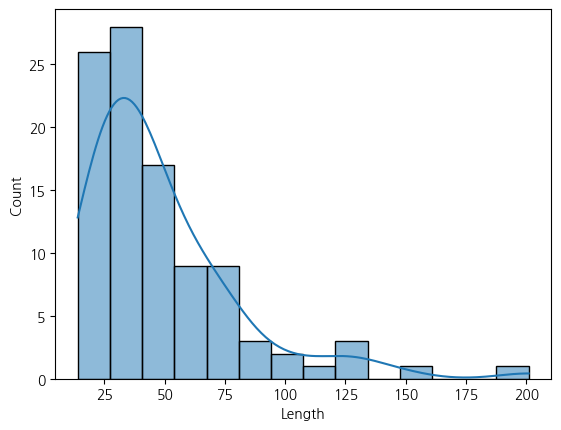

In [11]:
sns.histplot(df_copy['Length'], kde=True)

<Axes: xlabel='GeneralPolarity', ylabel='Length'>

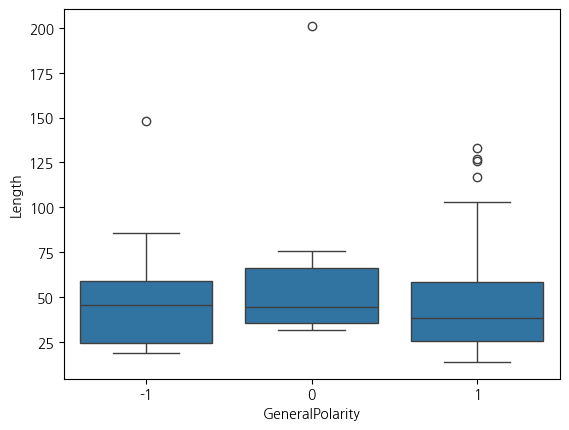

In [12]:
sns.boxplot(x='GeneralPolarity', y='Length', data=df_copy)

## 3. 리뷰 날짜(RDate) 분포

- 날짜 컬럼을 datetime으로 변환
- 전체 기간 동안 리뷰가 어떻게 분포하는지 확인

In [13]:
df_copy['RDate'] = pd.to_datetime(df['RDate'].astype(str), format='%Y%m%d')
df_copy

,RawText,Length,Word,GeneralPolarity,RDate
0,가격이 착하고 디자인이 예쁩니다,17,4,1,2021-08-15
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,31,8,1,2021-08-07
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,49,10,1,2021-08-04
3,너무 착한가격에 감사합니다 윈하는 색은 없지만,25,6,1,2021-08-03
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,52,11,1,2021-07-17
...,...,...,...,...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,52,11,1,2021-10-29
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,39,9,1,2021-10-27
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,71,2,1,2021-10-23
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,127,26,1,2021-10-01


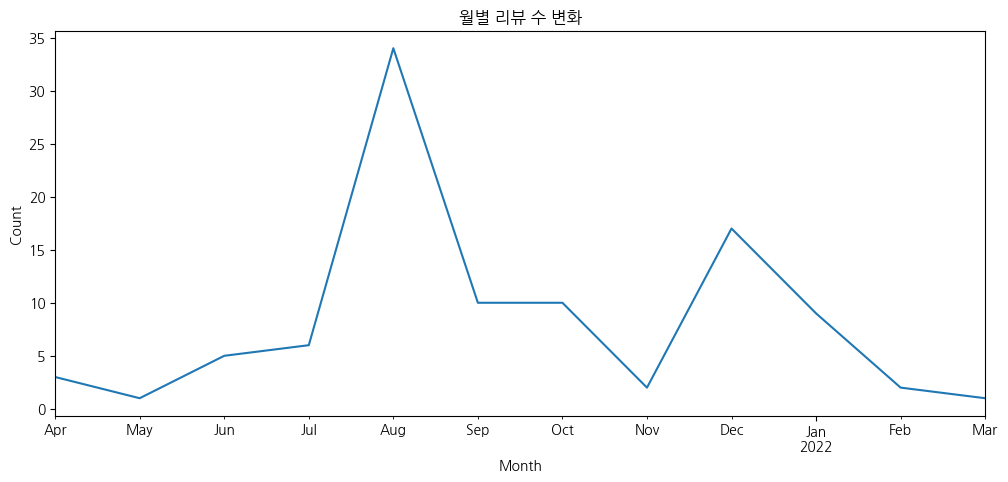

In [14]:
daily = df_copy.groupby(df_copy['RDate'].dt.to_period('M')).size()

daily.plot(kind='line', figsize=(12,5))
plt.title("월별 리뷰 수 변화")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

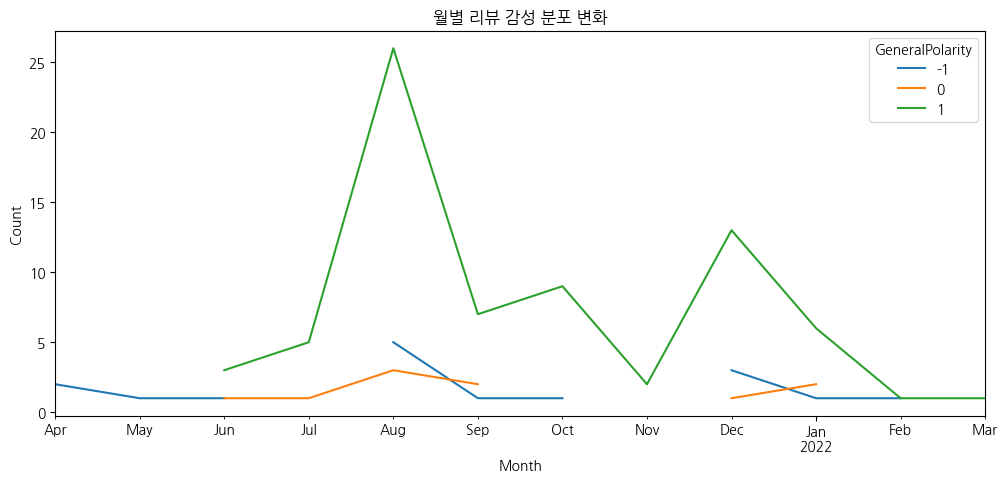

In [15]:
sent_daily = df_copy.groupby([df_copy['RDate'].dt.to_period('M'), 'GeneralPolarity']).size()
sent_daily.unstack().plot(figsize=(12,5))
plt.title("월별 리뷰 감성 분포 변화")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

## 4. ReviewScore 분포 및 길이와의 관계

In [16]:
df_copy['ReviewScore'] = df['ReviewScore']
df_copy

,RawText,Length,Word,GeneralPolarity,RDate,ReviewScore
0,가격이 착하고 디자인이 예쁩니다,17,4,1,2021-08-15,100
1,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,31,8,1,2021-08-07,100
2,편하고 디자인이 예뻐요 가격도 좋아요 시원해요 빨리 마르고 이것만 입게되요,49,10,1,2021-08-04,100
3,너무 착한가격에 감사합니다 윈하는 색은 없지만,25,6,1,2021-08-03,100
4,가격이 너무 좋아서 블랙 구매했습니다 그런데 소재도 맘에 들어 흰색도 ...,52,11,1,2021-07-17,100
...,...,...,...,...,...,...
95,가격대비 훌륭합니다 조끼만 다른분들 상품평처럼 좀 싼티는나지만 그래도 잘 입을듯요...,52,11,1,2021-10-29,100
96,가격대비 넘넘 맘에 들어요 특히 기모가 있어서. 외출복으로도 좋아요,39,9,1,2021-10-27,100
97,의류안에 기모가아닌베로아로되어서더욱따뜻함니다저렴한가격으로구매해서더욱좋아요타방송보다훨...,71,2,1,2021-10-23,100
98,티와 바진ㄷㄴ 따듯 하겠고 질도 좋은데 베스트는 생각보다는 도톰하고 ...,127,26,1,2021-10-01,100


In [17]:
df_copy['ReviewScore'].value_counts()

,count
ReviewScore,
100,68
80,11
60,7
70,6
50,3
90,2
10,1
20,1
40,1


<Axes: xlabel='Length', ylabel='ReviewScore'>

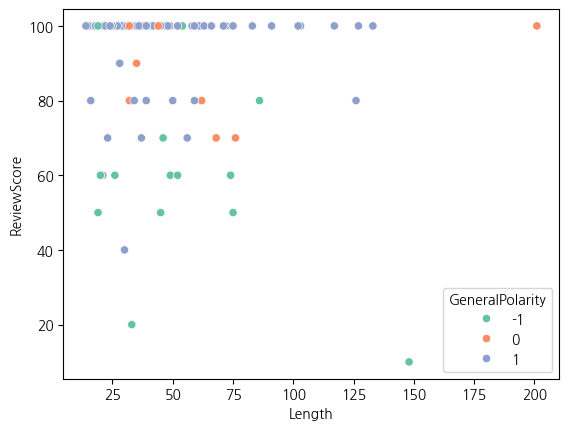

In [18]:
sns.scatterplot(x='Length', y='ReviewScore', data=df_copy, hue='GeneralPolarity', palette='Set2')

## 5. GeneralPolarity(전체 감성) 분포

- -1: 부정, 0: 중립, 1: 긍정

In [19]:
df_copy['GeneralPolarity'].value_counts()

,count
GeneralPolarity,
1,74
-1,16
0,10


<Axes: xlabel='GeneralPolarity', ylabel='count'>

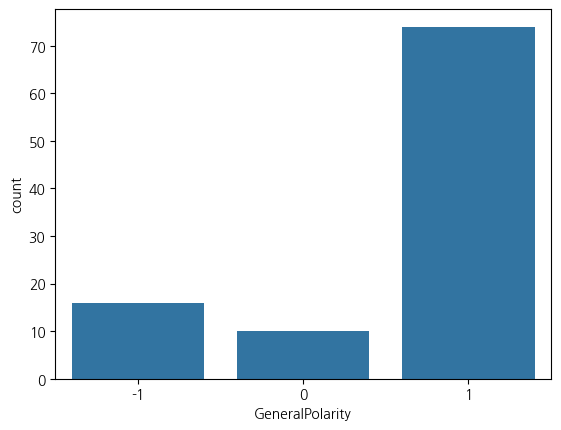

In [20]:
sns.countplot(x='GeneralPolarity', data=df_copy)

## 6. Aspect 기반 EDA

- Aspects 컬럼을 행 단위로 풀어서 하나의 DataFrame(`aspect_df`) 생성
- Aspect 종류별 빈도
- Aspect별 감성 분포(-1/0/1)
- "사이즈" / "가격"에 대한 감성과 ReviewScore 관계 보기

In [21]:
aspect_df = df.explode('Aspects')
aspect_df.head()

,Index,RawText,Source,Domain,MainCategory,ProductName,ReviewScore,Syllable,Word,RDate,GeneralPolarity,Aspects
0,7,가격이 착하고 디자인이 예쁩니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,17,4,20210815,1,"{'Aspect': '가격', 'SentimentText': '가격이 착하고', '..."
0,7,가격이 착하고 디자인이 예쁩니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,17,4,20210815,1,"{'Aspect': '디자인', 'SentimentText': '디자인이 예쁩니다'..."
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '가격', 'SentimentText': '싸고', 'Senti..."
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '디자인', 'SentimentText': '디자인이 예뻐요',..."
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '가격', 'SentimentText': '가성비 가심비 입니다..."


In [22]:
aspect, sentiment_text, sentiment_word, sentiment_polarity = [], [], [], []
for i in aspect_df.iterrows():
  aspect.append(i[1]['Aspects']['Aspect'])
  sentiment_text.append(i[1]['Aspects']['SentimentText'])
  sentiment_word.append(i[1]['Aspects']['SentimentWord'])
  sentiment_polarity.append(i[1]['Aspects']['SentimentPolarity'])

aspect_df['Aspect'] = aspect
aspect_df['SentimentText'] = sentiment_text
aspect_df['SentimentWord'] = sentiment_word
aspect_df['SentimentPolarity'] = sentiment_polarity
aspect_df.head()

,Index,RawText,Source,Domain,MainCategory,ProductName,ReviewScore,Syllable,Word,RDate,GeneralPolarity,Aspects,Aspect,SentimentText,SentimentWord,SentimentPolarity
0,7,가격이 착하고 디자인이 예쁩니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,17,4,20210815,1,"{'Aspect': '가격', 'SentimentText': '가격이 착하고', '...",가격,가격이 착하고,2,1
0,7,가격이 착하고 디자인이 예쁩니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,17,4,20210815,1,"{'Aspect': '디자인', 'SentimentText': '디자인이 예쁩니다'...",디자인,디자인이 예쁩니다,2,1
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '가격', 'SentimentText': '싸고', 'Senti...",가격,싸고,1,1
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '디자인', 'SentimentText': '디자인이 예뻐요',...",디자인,디자인이 예뻐요,2,1
1,9,싸고 디자인이 예뻐요. . 정말 가성비 가심비 입니다,쇼핑몰,패션,여성의류,OO 플** 베스트 풀코디 3종,100,31,8,20210807,1,"{'Aspect': '가격', 'SentimentText': '가성비 가심비 입니다...",가격,가성비 가심비 입니다,3,1


<Axes: xlabel='Aspect', ylabel='count'>

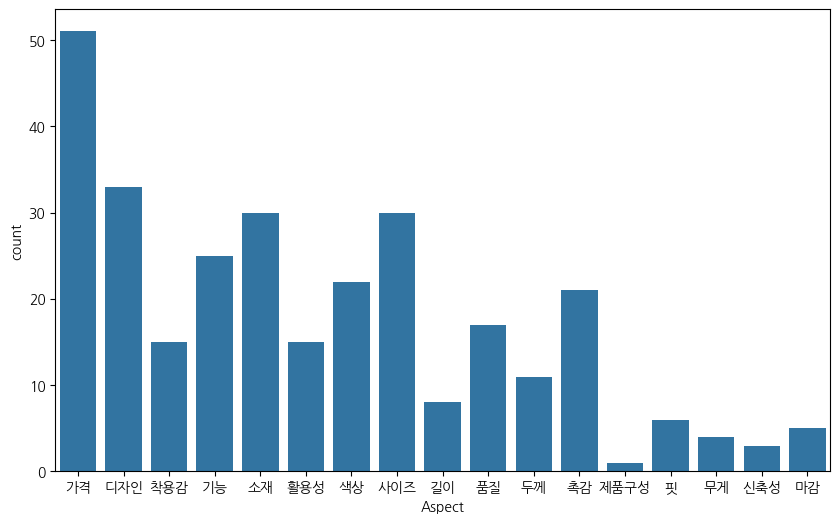

In [23]:
# Aspect 종류별 빈도
plt.figure(figsize=(10,6))
sns.countplot(x='Aspect', data=aspect_df)

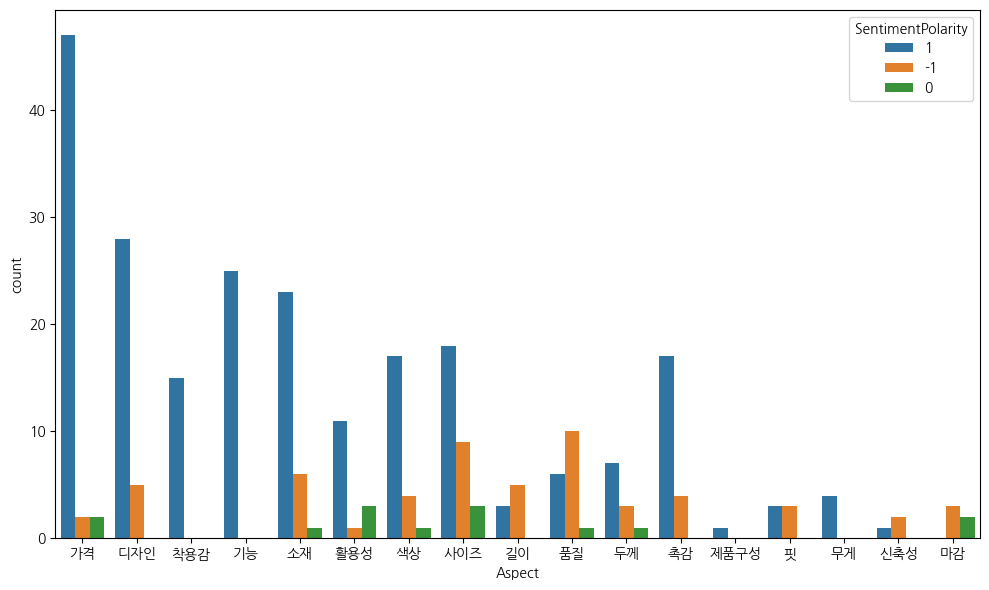

In [24]:
# Aspect별 감성 분포
plt.figure(figsize=(10,6))
sns.countplot(x='Aspect', hue='SentimentPolarity', data=aspect_df)

plt.tight_layout()
plt.show()

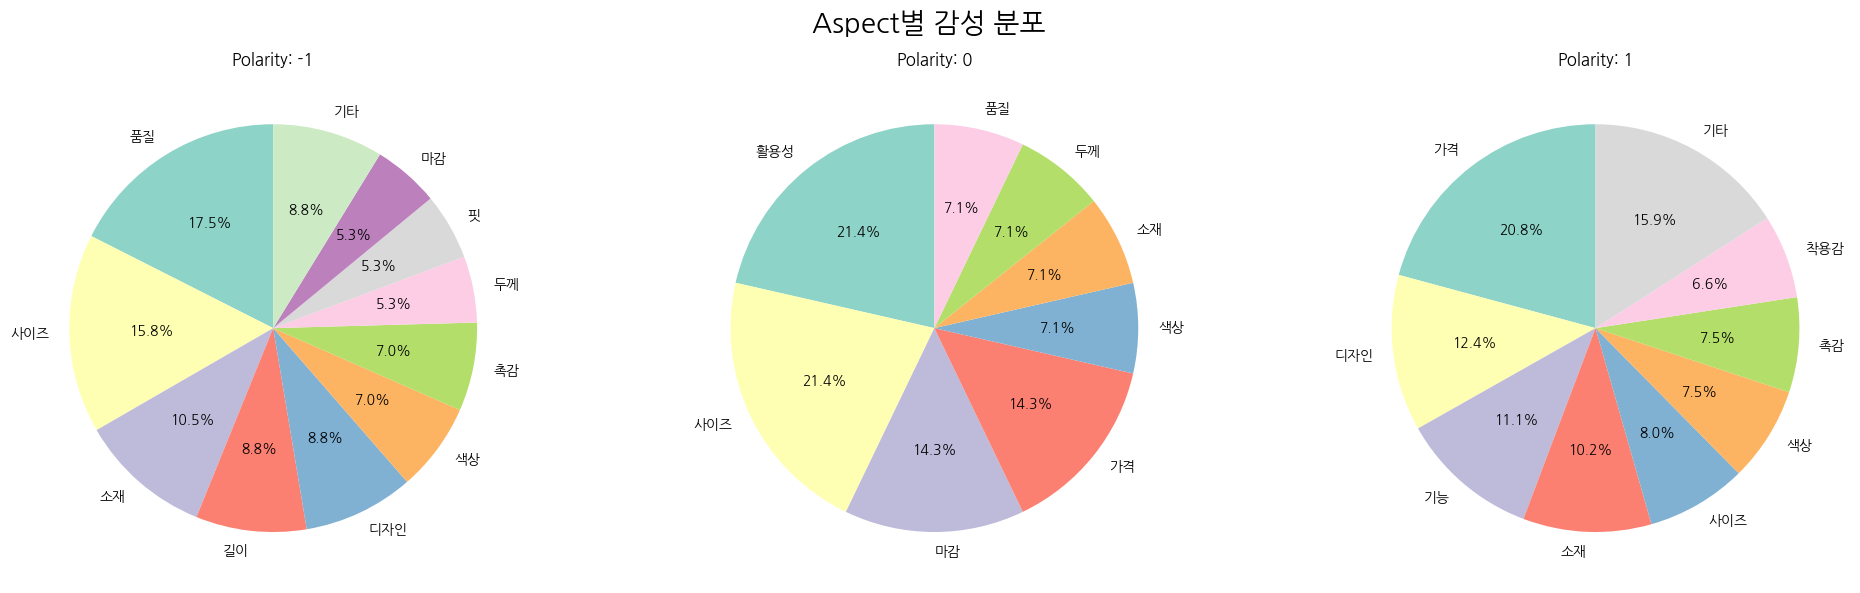

In [25]:
# 감성별 Aspect 파이 그래프
fig, axes = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('Aspect별 감성 분포', fontsize=20)
for i, polarity in enumerate(range(-1,2)):
    polarity = str(polarity)
    ax = axes[i]
    # 해당 감성만 필터링
    subset = aspect_df[aspect_df['SentimentPolarity'] == polarity]

    # Aspect별 개수 집계
    counts = subset['Aspect'].value_counts()

    # 비율 계산
    ratio = counts / counts.sum()
    # 임계값 이하 항목은 '기타'로 묶기
    small = ratio[ratio < 0.05].index

    # 기타 묶기
    if len(small) > 0:
        counts = counts.copy()
        counts.loc['기타'] = counts[small].sum()
        counts = counts.drop(small)


    ax.set_title(f'Polarity: {polarity}')
    # 데이터가 없을 경우 처리
    if counts.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=14)
        ax.set_title(f'Polarity: {polarity}')
        ax.axis('off')
        continue

    # Pie Chart 그리기
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10},
        colors = sns.color_palette('Set3')
    )

plt.tight_layout()
plt.show()

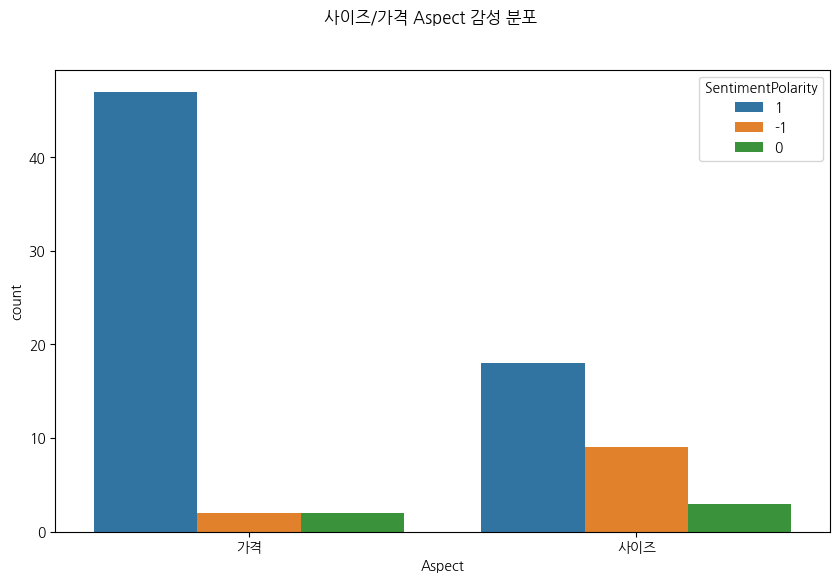

In [26]:
# 사이즈/가격 vs 감성
plt.figure(figsize=(10,6))
subset = aspect_df[aspect_df['Aspect'].isin(['사이즈', '가격'])]
sns.countplot(x='Aspect', hue='SentimentPolarity', data=subset)
plt.suptitle("사이즈/가격 Aspect 감성 분포")
plt.show()

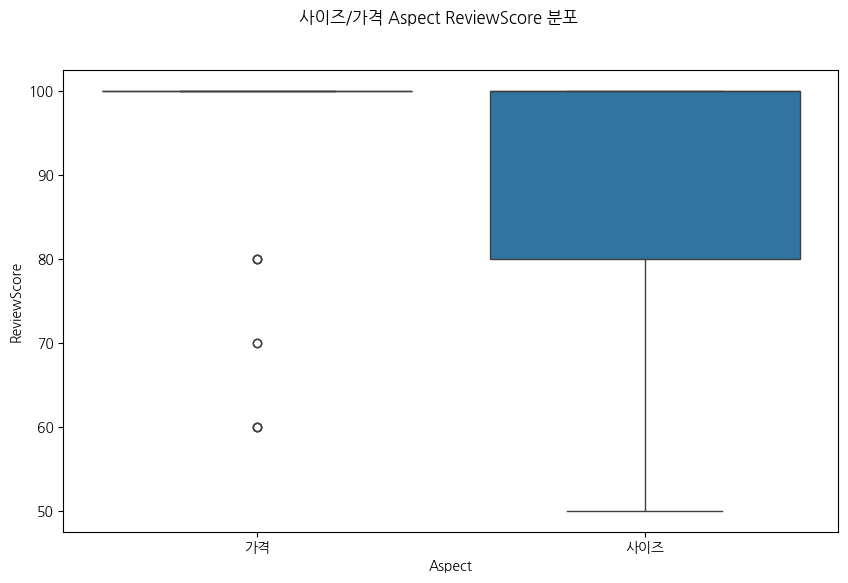

In [27]:
# 사이즈/가격 vs ReviewScore
plt.figure(figsize=(10,6))
subset = aspect_df[aspect_df['Aspect'].isin(['사이즈', '가격'])]
sns.boxplot(x='Aspect', y='ReviewScore', data=subset)
plt.suptitle("사이즈/가격 Aspect ReviewScore 분포")
plt.show()

## 7. 텍스트 기반 분석: N-gram(Count) / TF-IDF(긍/부정 상위 20개 단어 추출)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB

pos_texts = df[df['GeneralPolarity'] == 1]['RawText']
neg_texts = df[df['GeneralPolarity'] == -1]['RawText']

In [29]:
# 공백기준 토큰화
count = CountVectorizer()

# 긍정
X_pos_count = count.fit_transform(pos_texts)
pos_counts = pd.DataFrame(X_pos_count.toarray(), columns=count.get_feature_names_out()).sum().sort_values(ascending=False).head(20)
print("========긍정========")
print(pos_counts, '\n')

# 부정
X_neg_count = count.fit_transform(neg_texts)
neg_counts = pd.DataFrame(X_neg_count.toarray(), columns=count.get_feature_names_out()).sum().sort_values(ascending=False).head(20)
print("========부정========")
print(neg_counts, '\n')

========긍정========
좋아요      15
너무       10
맘에        9
디자인도      8
가격대비      8
만족합니다     6
디자인이      6
좋네요       6
따뜻하고      6
저렴하게      5
들어요       5
가격이       5
시원하고      5
가볍고       5
사이즈       5
합니다       5
소재도       4
부드럽고      4
예뻐요       4
좋고        4
dtype: int64 

========부정========
너무          3
그냥          2
상의는         2
목이          2
ㅜㅜ          2
약간          2
얇고          2
엄청나게        2
생각보다        2
바지는         2
하지만         2
특히          2
커서          2
갈색은         1
감촉이         1
같아요         1
갑어치밖에       1
겨드랑이같은곳도    1
66사이즈       1
각잡힌옷이       1
dtype: int64 



In [30]:
# 공백기준 토큰화
tfidf = TfidfVectorizer()

# 긍정
X_pos_tfidf = tfidf.fit_transform(pos_texts)
pos_tfidf = pd.DataFrame(X_pos_tfidf.toarray(), columns=tfidf.get_feature_names_out()).mean().sort_values(ascending=False).head(20)
print("========긍정========")
print(pos_tfidf, '\n')

# 부정
X_neg_tfidf = tfidf.fit_transform(neg_texts)
neg_tfidf = pd.DataFrame(X_neg_tfidf.toarray(), columns=tfidf.get_feature_names_out()).mean().sort_values(ascending=False).head(20)
print("========부정========")
print(neg_tfidf, '\n')

========긍정========
좋아요      0.044047
너무       0.031879
디자인도     0.029986
가격대비     0.029508
시원하고     0.028476
디자인이     0.027461
맘에       0.027157
따뜻하고     0.023829
가볍고      0.023802
예뻐요      0.021723
사이즈      0.021127
들어요      0.020178
만족합니다    0.020147
저렴하게     0.019514
좋네요      0.019349
색상도      0.019227
예쁘고      0.018107
최고       0.017587
가격이      0.017499
부드럽고     0.017454
dtype: float64 

========부정========
얇고         0.049006
바지는        0.045131
너무         0.043936
약간         0.040492
그냥         0.039276
목이         0.038430
생각보다       0.038341
상의는        0.037160
특히         0.033657
감촉이        0.031250
까끌거려요      0.031250
많이         0.031250
옷이많이크네요    0.031250
커서         0.030458
하지만        0.030408
촉감이        0.030227
깔깔해요       0.030227
별로         0.028652
생객보다       0.028652
덜해서        0.028652
dtype: float64 



## 8. Aspect별 대표 문장 살펴보기

- 사이즈 부정 문장 Top 20
- 가격 긍정 문장 Top 20

In [31]:
len(aspect_df[
    (aspect_df['Aspect'] == '사이즈') &
    (aspect_df['SentimentPolarity'] == '-1')
]['RawText'].unique())

8

In [32]:
len(aspect_df[
    (aspect_df['Aspect'] == '가격') &
    (aspect_df['SentimentPolarity'] == '1')
]['RawText'].unique())

44

## 9. 워드클라우드


In [33]:
font_path

'/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

In [34]:
text_all = ' '.join(df['RawText'])
text_all

'가격이 착하고 디자인이 예쁩니다 싸고  디자인이 예뻐요. . 정말  가성비 가심비 입니다 편하고  디자인이 예뻐요  가격도  좋아요   시원해요  빨리 마르고  이것만  입게되요 너무 착한가격에 감사합니다 윈하는 색은 없지만 가격이  너무 좋아서  블랙 구매했습니다  그런데 소재도  맘에  들어  흰색도  구매했습니다 외출할때 입기에는 재질도 디자인도 좀~그러네요 그냥 집에서 편하게 입을수는 있을것 같아요 특히 자켓이 넘작고 짧으네요. 상의는 좀작구 바지는 잘맞아요. 싸고품질이좋아요ᆢ사이즈는좀큰듯하구요ᆢ반사이즈는내려서주문하심좋을듯해요 바지가 너무 편하고 좋아요 티셔츠는 여름에 잘 입을 듯 베스트는 디자인은 별로지만 가격이 착해서 만족 디자인이 예뻐요. 사이즈 잘 맞습니다. 사이즈 딱 맞구요.  너무 예쁘고  얇지도 두껍지도 않으네요. 저렴하게 구입해서 겨울에 잘 입을거 같아요 털이 엄청나게 빠집니다 면 바바리에 엄청나게 묻어나고  하루입고벗었더니 겨드랑이같은곳도 엄청 뭉처있니에요 그래서 세탁을 했더니 끝도없이 손에 털뭉치???? 들이 묻어나서 포기했습니다 이게불량인가요 왜이렇게 만드신건가요 옷디자인은 너무맘에드는데 털빠짐때매 옷이아니네여 디자인이 여성스러운 분위기가 납니다 구겨져와서 다림질 필요했어요 99사이즈 입는데 88 사이즈 잘맞고~ 기장이 살짝 짧은듯 하지만 밝은색도 있고~ 까실까실하니 좋으네요~ 4종 마음에 들어요 색깔도 이쁘고 여름니트 입니다 색상이 예쁘고  구김이없어요 색상 디자인 예쁘고 맘에들어요 가성비 갑입니다 가로패턴이라 더커 보이면 어쩌나 싶었는데 칼라고 디자인이고 다 만족합니다  가슴도  좀있는편이라  걱정했는데 핏이 괸찮아요  비치지 않아서 하나만 입고 다녀도될만 합니다 오 좋아요 이가격에 득템 했네요 살이쪄서 고민이었는데 어지간히 커버도 되고 가볍고 시원할듯 해요 잘 입을께요 바로 세탁하느라 시착만 해서 사진은 스크린샷 으로 대체해요 사진하고 똑 같으니 걱정마세요 추천 합니다 가격대비 최고예요 가볍고 좋아요 그레이상의는 비침이 약간있

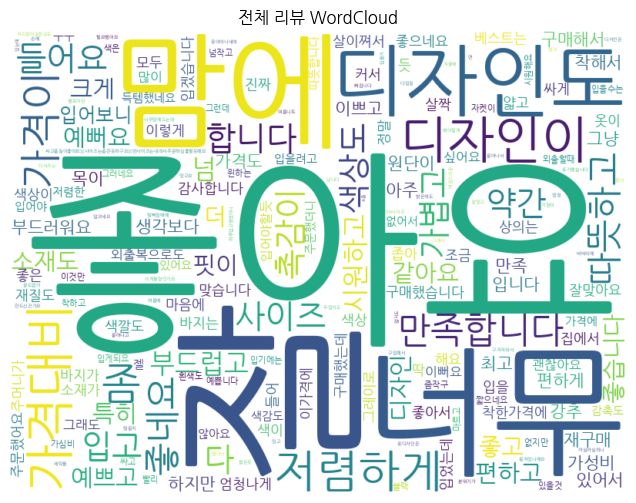

In [39]:
from wordcloud import WordCloud

wc = WordCloud(background_color='white', font_path=font_path, width=800, height=600)
wc.generate(text_all)
plt.figure(figsize=(8,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('전체 리뷰 WordCloud')
plt.show()